In [23]:
import sunpy
import sunpy.map
from map_coalign import MapSequenceCoalign
from glob import glob
import astropy.units as u
import matplotlib.animation as animation

import matplotlib.pyplot as plt
from astropy.io.fits import CompImageHDU

import os

In [2]:
map_files = sorted(glob("../../data/20241015/hri/*.fits"))

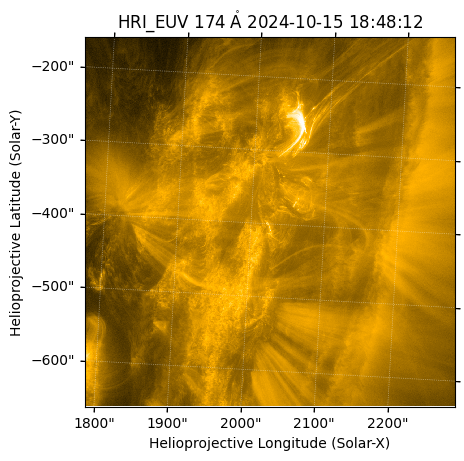

In [13]:
test_map = sunpy.map.Map(map_files[180])
test_map = test_map.submap(bottom_left=(800, 400)*u.pix,
                           top_right=(800+1024-1, 400+1024-1)*u.pix)
test_map.plot()

In [18]:
ms = MapSequenceCoalign(sunpy.map.Map(map_files[:]))
ms = ms.submap(bottom_left=(800, 400)*u.pix,
               top_right=(800+1024-1, 400+1024-1)*u.pix)

In [19]:
len(map_files)

1012

In [20]:
ms.coalign(reference_index=0,bottom_left=[256, 128], top_right=[512+128, 128+256],
            check_header=False, nframes=8, iter=3)

--------Starting iteration 1/3--------


100%|██████████| 127/127 [02:46<00:00,  1.31s/it]


--------Iteration 1/3 finished--------
--------Starting iteration 2/3--------


100%|██████████| 127/127 [02:50<00:00,  1.34s/it]


--------Iteration 2/3 finished--------
--------Starting iteration 3/3--------


100%|██████████| 127/127 [02:49<00:00,  1.34s/it]


--------Iteration 3/3 finished--------


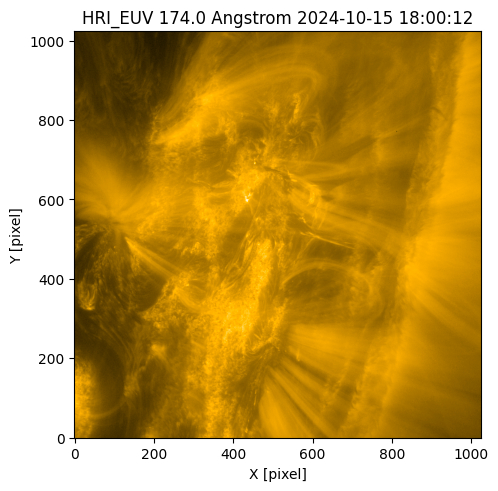

In [24]:
anim = ms.plot(no_wcs=True)
anim.save("../../figs/test_movie/hrieuv_20241015_coalign.mp4")

In [25]:
ms.save(os.path.join("../../data/20241015/hri_coalign/","hrieuv_20241015_coalign_{index:03}.fits"), overwrite=True)